# Molecules and Coupled Equilibrium

*Stellar Spectroscopy from Scratch — from physical principles to a working code*

Chapter 3 ended with a closed atom-only picture. For a trial electron density, each
element occupied its own ionization ladder; charge conservation then selected the
shared electron density that made all of those ladders consistent. Carbon nuclei
moved among C I, C II, and higher stages, while oxygen nuclei moved along a separate
ladder.

A single CO molecule breaks that separation. It owns one carbon nucleus and one
oxygen nucleus at the same time. If we remove too much carbon from the free-carbon
pool, the CO abundance changes, which changes the oxygen budget too. The gas can no
longer be closed one element at a time.

This gives us the question for the chapter:

> Given `temperature`, material `gas_pressure`, and the Chapter 3 elemental
> mixture, how do we assign positive atomic, ionic, molecular, and electron
> densities while conserving every elemental budget and the total particle budget?

We will build the answer in three movements. First, mass action will tell us how
many molecules exist *for a trial set of free densities*. Conservation will then
turn that conditional statement into one coupled vector root. Next, we will make
Newton's method positive and follow its solution through an ordered atmosphere.
Finally, we will see how the atmosphere and synthesis implementations preserve the
same chemistry while making different numerical and public-state choices.

The assumptions remain deliberately narrow: an ideal gas in local thermodynamic
equilibrium, a static plane-parallel depth coordinate, CGS number densities, and
depth index 0 outermost. We do not calculate opacity or a spectrum here. Our goal is
the closed population state that those later calculations require.

The construction contract is compact:

| role | chapter object |
|---|---|
| reads | depth vectors `temperature`, `gas_pressure`, `column_mass`, `microturbulence`, and an electron seed; one `(99,)` linear abundance vector; exact molecular catalogs and thermochemical tables |
| solves | one 23-entry ordinary-density vector per depth, in cm\(^{-3}\), by ordered continuation |
| writes | raw 170- or 190-record molecular populations, saved physical and transformed equation arrays, molecular energy in the atmosphere route, an 18-field atmosphere-continuum adapter, and a separate 27-field schema-v4 synthesis handoff |
| numerical owners | atmosphere: CPU NumPy/Numba `float64`; synthesis: explicit PyTorch device and dtype |

> **Movement I — One molecule couples two budgets.** We begin with one transparent
> association reaction, attach it to the real CO catalog record, and discover why
> mass action must be solved together with conservation.


In [1]:
from pathlib import Path
import sys

repository_root = Path.cwd()
if repository_root.name == "content":
    repository_root = repository_root.parent
if str(repository_root) not in sys.path:
    sys.path.insert(0, str(repository_root))
source_root = repository_root / "src"
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

from book.plot_style import apply_book_plot_style

apply_book_plot_style()


In [2]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from book.chapter04_runtime import (
    ATMOSPHERE_MOLECULAR_TABLES,
    ATMOSPHERE_MOLECULE_CATALOG,
    MOLECULAR_INPUT_FIXTURE,
    SYNTHESIS_ATOMIC_MASSES,
    SYNTHESIS_CONTINUUM_EDGE_GRID,
    SYNTHESIS_EOS_TABLES,
    SYNTHESIS_MOLECULE_CATALOG,
    atmosphere_continuation_checkpoint,
    atmosphere_jacobian_checkpoint,
    atmosphere_linear_solve_checkpoint,
    atmosphere_newton_update_witness,
    build_public_molecular_lane_checkpoint,
    compute_atmosphere_molecular_state,
    compute_synthesis_molecular_state,
    configure_local_data_paths,
    h2_formation_policy_curves,
    h2_partition_table_probe,
    load_molecular_inputs,
    load_npz_arrays,
    molecular_catalog_summary,
    molecular_route_boundary_checkpoint,
)
from book.chapter04_synthesis_checkpoint import (
    synthesis_newton_checkpoint,
)
from book.chapter04_teaching import (
    decode_base100_molecule_code,
    solve_two_element_molecule,
    two_element_molecule_residual,
)
from book.plot_style import PAPER_COLORS, add_quiet_grid, single_panel
from payne_zero_atmosphere.constants import (
    BOLTZMANN_ERG_PER_K_REFERENCE,
)
from payne_zero_atmosphere.molecular_data import (
    read_molecular_equilibrium_catalog,
)
from payne_zero_atmosphere.population_layout import (
    population_job_schedule,
)
from payne_zero_synthesis.constants import (
    REFERENCE_ATOMIC_MASS_GRAM,
    REFERENCE_BOLTZMANN_ERG_PER_K,
)

configure_local_data_paths()
molecular_inputs = load_molecular_inputs()
golden_directory = (
    repository_root / "data" / "golden" / "payne_zero" / "chapter04"
)

manifest = json.loads(
    (repository_root / "data" / "MANIFEST.json").read_text()
)
manifest_hash = {
    (repository_root / entry["path"]).resolve(): entry["sha256"]
    for entry in manifest["entries"]
}


## 4.1 Bind the chemistry to exact data

Before writing a chemical equation, we must identify what the word *molecule*
means to the calculation. A molecular catalog contains more than names. It fixes
the record order, formation coefficients, component multiplicities, and the
equation row assigned to each free species. Its active length is physical; its
padded length is only storage capacity.

We therefore start with a compact preflight rather than a source-file tour. The
two catalogs below live inside this book and are checksum-bound by the data
manifest. They share 23 active equation rows, but they do not have the same number
or order of molecular records.


In [3]:
catalog_summary = molecular_catalog_summary()
assets = {
    "atmosphere chemistry": ATMOSPHERE_MOLECULE_CATALOG,
    "synthesis chemistry": SYNTHESIS_MOLECULE_CATALOG,
    "atmosphere H2 table": ATMOSPHERE_MOLECULAR_TABLES,
    "synthesis atomic masses": SYNTHESIS_ATOMIC_MASSES,
    "synthesis partition/Saha": SYNTHESIS_EOS_TABLES,
    "continuum-edge grid": SYNTHESIS_CONTINUUM_EDGE_GRID,
    "declared six-depth input": MOLECULAR_INPUT_FIXTURE,
}
print("role                     SHA-256 prefix   manifest verified")
for role, path in assets.items():
    digest = hashlib.sha256(Path(path).read_bytes()).hexdigest()
    print(f"{role:24s} {digest[:12]}        ",
          digest == manifest_hash[Path(path).resolve()])
print(
    "atmosphere catalog       ",
    catalog_summary["atmosphere_counts"].tolist(),
)
print(
    "synthesis catalog        ",
    catalog_summary["synthesis_counts"].tolist(),
)
abundance = molecular_inputs["elemental_abundances"]
print("depth count / abundance shape:", molecular_inputs["temperature"].size,
      abundance.shape)
print("abundance sum retained:", np.sum(abundance))


role                     SHA-256 prefix   manifest verified
atmosphere chemistry     971525641062         True
synthesis chemistry      3e8c1ea69fe6         True
atmosphere H2 table      1e23fbfdca30         True
synthesis atomic masses  d4739fef7e03         True
synthesis partition/Saha 83e7708b0ca9         True
continuum-edge grid      11b77ecf752f         True
declared six-depth input 351bba75dca1         True
atmosphere catalog        [170, 23, 481]
synthesis catalog         [190, 23, 548]
depth count / abundance shape: 6 (99,)
abundance sum retained: 0.9999996127701212


The atmosphere catalog has 170 active molecule records, 23 equation rows, and 481
component entries. The synthesis catalog has 190, 23, and 548. Equal equation
width does not make the records interchangeable. Later we will align them by
chemical identity, not by row number.

Every required file matches its manifest entry. That binds the calculation to
exact bytes; it does not prove that the chemistry is physically correct. Notice
also that the nearly unit abundance sum is retained rather than silently
renormalized. The physical test begins with one transparent reaction.

## 4.2 Close a two-body association reaction

Let \(x_0\) be a nuclei-density scale and let \(x_A\) and \(x_B\) be the free
densities of two elements. For a declared formation constant \(K\), mass action
predicts

\[
n_{AB}=Kx_Ax_B .
\]

If the linear elemental abundances are \(A_A\) and \(A_B\), then a molecule spends
one nucleus from each budget:

\[
x_A+n_{AB}=A_Ax_0,\qquad
x_B+n_{AB}=A_Bx_0.
\]

Substitute \(x_A=A_Ax_0-n_{AB}\) and \(x_B=A_Bx_0-n_{AB}\). One unknown
remains:

\[
n_{AB}=K(A_Ax_0-n_{AB})(A_Bx_0-n_{AB}).
\]

The quadratic has two algebraic roots, but only one lies between zero and the
smaller elemental budget. Directly subtracting the two large terms in the usual
quadratic formula would lose precision when little \(AB\) forms. The stable
positive form is

\[
n_{AB}=
\frac{2KB_AB_B}
{1+K(B_A+B_B)+
\sqrt{[1+K(B_A+B_B)]^2-4K^2B_AB_B}},
\]

where \(B_A=A_Ax_0\) and \(B_B=A_Bx_0\). Here \(K\) has units cm\(^3\),
so every density retains units cm\(^{-3}\).


In [4]:
def stable_association_population(nuclei_density, abundances, constant):
    budgets = abundances * nuclei_density
    linear = 1.0 + constant * np.sum(budgets)
    discriminant = linear**2 - 4.0 * constant**2 * np.prod(budgets)
    return (
        2.0 * constant * np.prod(budgets)
        / (linear + np.sqrt(max(discriminant, 0.0)))
    )

abundances_ab = np.array([0.6, 0.4])
cases = (
    ("large K, low density ", 1.0e-14, 1.0e12),
    ("large K, high density", 1.0e-14, 1.0e16),
    ("small K, low density ", 1.0e-18, 1.0e12),
    ("small K, high density", 1.0e-18, 1.0e16),
)
print("case                       n_AB [cm-3]   limiting fraction   max scaled R")
for label, formation_constant, nuclei_density in cases:
    molecule = stable_association_population(
        nuclei_density, abundances_ab, formation_constant
    )
    budgets = abundances_ab * nuclei_density
    free = budgets - molecule
    residual = np.array([
        molecule - formation_constant * free[0] * free[1],
        free[0] + molecule - budgets[0],
        free[1] + molecule - budgets[1],
    ])
    scales = np.array([max(molecule, 1.0), *budgets])
    print(
        f"{label:26s} {molecule:11.4e}          "
        f"{molecule / budgets.min():8.6f}       "
        f"{np.max(np.abs(residual) / scales):.2e}"
    )


case                       n_AB [cm-3]   limiting fraction   max scaled R
large K, low density        2.3763e+09          0.005941       0.00e+00
large K, high density       3.8242e+15          0.956059       1.10e-14
small K, low density        2.4000e+05          0.000001       1.21e-16
small K, high density       2.3763e+13          0.005941       0.00e+00


At fixed \(K\), increasing density raises the molecular fraction because
association requires two free particles to meet. At fixed density, the declared
larger \(K\) produces more \(AB\). These labels do not yet say that cooler gas
always makes more molecules; that direction must come from the actual \(K(T)\).

This is the first distinction to keep: mass action predicts a population from
*free* densities; conservation decides which free densities are allowed. We have
closed two elemental ledgers while holding \(x_0\) fixed. We have not yet closed
the gas-pressure ledger.

## 4.3 Attach the symbols to the real CO record

The atmosphere catalog labels CO with code `608`. Reading decimal digits by eye is
useful intuition—6 is carbon and 8 is oxygen—but it is not the authority. The
component offsets and equation indices are. We inspect those arrays for one record
and use a base-100 decode only as a cross-check.


In [5]:
atmosphere_catalog = read_molecular_equilibrium_catalog(
    ATMOSPHERE_MOLECULE_CATALOG
)
active_codes = atmosphere_catalog.molecule_codes[
    : atmosphere_catalog.molecule_count
]
co_row = int(np.flatnonzero(np.isclose(active_codes, 608.0))[0])
start = int(atmosphere_catalog.component_start_indices[co_row])
stop = int(atmosphere_catalog.component_start_indices[co_row + 1])
equation_rows = atmosphere_catalog.component_equation_indices[start:stop]
species = atmosphere_catalog.equation_species_codes[equation_rows]
decoded, charge = decode_base100_molecule_code(608.0)
print("catalog code:", active_codes[co_row])
print("component species:", species.tolist(), "(C=6, O=8)")
print("equation rows:", equation_rows.tolist())
print("independent base-100 check:", decoded, "charge:", charge)


catalog code: 608.0
component species: [6, 8] (C=6, O=8)
equation rows: [6, 8]
independent base-100 check: (6, 8) charge: 0


CO is one catalog population but contributes to two elemental residual rows. That
repeated contribution is the coupling we need to solve.

## 4.4 Formation constants are policies, not universal functions

A formation constant converts trial component densities into a molecular
population. Both catalog assets allocate a `(7, 200)` coefficient buffer, but
they activate different polynomial widths. Let \(C_m\) be the number of encoded
components and let \(q_m^+\) be the nonnegative ion charge encoded in the
fractional part of the record code. The atmosphere law consumes
\(c_0,\ldots,c_5\); its seventh stored row is zero. It evaluates

\[
\ln K_m^{\rm atm}=
\frac{c_0}{T/11604.5}-c_1+c_2T-c_3T^2+c_4T^3-c_5T^4
-\frac32(C_m-2q_m^+-1)\ln T .
\]

Synthesis stores a seventh, quintic coefficient:

\[
\ln K_m^{\rm syn}=
\frac{a_0}{k_{\rm B}T\,[{\rm eV}]}-a_1+a_2T-a_3T^2+a_4T^3-a_5T^4+a_6T^5
-\frac32(C_m-2q_m^+-1)\ln T .
\]

In either table the leading coefficient is an energy in eV; the remaining
coefficient units make the exponent dimensionless. A zero leading coefficient
selects a different physical branch. A one-component atom or ion uses \(K_m=1\);
a multi-component ion obtains \(K_m\) from the Chapter 3 Saha fractions and an
electron-density power. In the atmosphere backend, those Saha-derived constants
use the pre-solve runtime electron and charge-square densities and remain frozen
during Newton. Synthesis constructs the analogous ion constants from its
separately declared molecular electron seed. These rows must not be evaluated
with either dissociation polynomial.

H\(_2\) is especially instructive because three exact policies meet here. The
atmosphere has a dedicated partition-table helper and keeps the catalog branch
active through 20,000 K. The synthesis molecular catalog applies its polynomial
only through 10,000 K. The public structured builder also forms a provisional H2
estimate through 9,000 K before the solved molecular value replaces it. These
boundaries are implementation contracts, not interchangeable approximations.


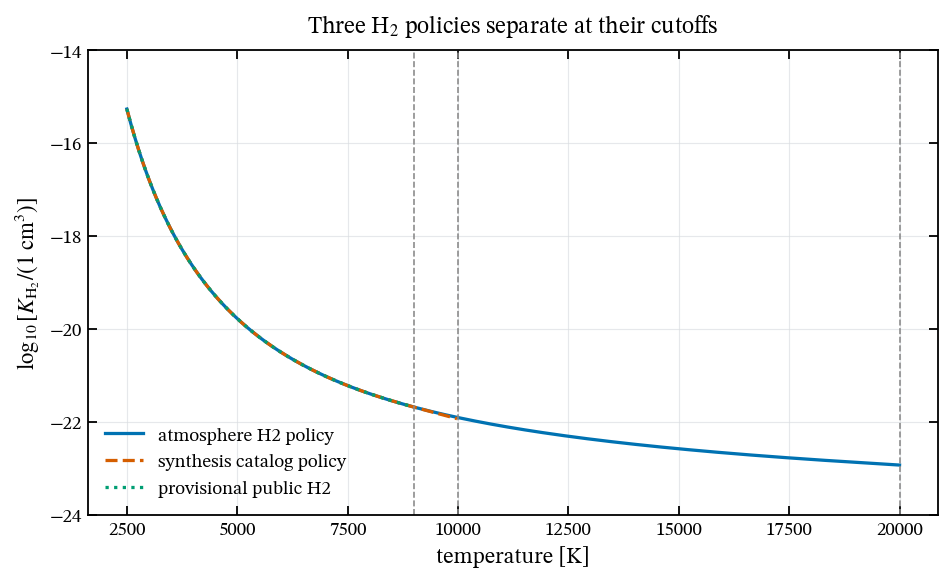

H2 partition Q: [  0.667     0.67373 147.67    147.67    182.798   182.798   658.10609
 658.16    658.16    658.16   ]
atmosphere H2 policy [1.206e+202 6.996e+199 2.070e-022 2.070e-022 1.228e-022 1.228e-022
 1.188e-023 1.187e-023 1.163e-023 0.000e+000]
synthesis catalog policy [3.746e+202 2.154e+200 2.065e-022 2.065e-022 1.145e-022 0.000e+000
 0.000e+000 0.000e+000 0.000e+000 0.000e+000]
provisional public H2 [3.800e+202 2.185e+200 2.065e-022 0.000e+000 0.000e+000 0.000e+000
 0.000e+000 0.000e+000 0.000e+000 0.000e+000]


In [6]:
temperature_grid = np.geomspace(2500.0, 22000.0, 320)
h2_policies = h2_formation_policy_curves(temperature_grid)
figure, axes = single_panel()
styles = (("blue", "-"), ("orange", "--"), ("green", ":"))
for (label, values), (color_name, line_style) in zip(
    h2_policies.items(), styles):
    positive = values > 0.0
    axes.plot(
        temperature_grid[positive],
        np.log10(values[positive]),
        label=label,
        color=PAPER_COLORS[color_name],
        ls=line_style)
for boundary in (9000.0, 10000.0, 20000.0):
    axes.axvline(boundary, color=PAPER_COLORS["grey"], lw=0.9, ls="--")
axes.set(xlabel="temperature [K]",
         ylabel=r"$\log_{10}[K_{\mathrm{H_2}}/(1\ \mathrm{cm^3})]$",
         title="Three H$_2$ policies separate at their cutoffs",
         ylim=(-24.0, -14.0))
add_quiet_grid(axes)
axes.legend()
plt.show()
plt.close(figure)

edges = np.array([
    100.0, 101.0,
    9000.0, np.nextafter(9000.0, np.inf),
    10000.0, np.nextafter(10000.0, np.inf),
    19899.0, 19900.0,
    20000.0, np.nextafter(20000.0, np.inf),
])
print("H2 partition Q:", h2_partition_table_probe(edges))
for label, values in h2_formation_policy_curves(edges).items():
    print(label, np.array2string(values, precision=3))


The smooth curves explain scale; the printed deterministic probes own the branch
statement. For the atmosphere table, 100 K is the low clamp and 101 K is the first
interpolation step; 19,899 K is the last interpolation step and 19,900 K is the
high clamp. The separate 20,000 K test is the catalog activity gate, not another
interpolation boundary. Notice also what is *not* on the axis: a raw formation
constant \(K_m\), a raw population \(n_m\), and a partition-normalized population
\(n_m/U_m\) are different objects.

<figure>
  <img src="assets/schematics/textbook/ch04-coupled-budgets-v1.png"
       alt="A carbon ledger and an oxygen ledger both feed one central CO molecule, so the same CO token is subtracted from both elemental budgets.">
  <figcaption><strong>Conceptual map: one molecule spends two
  ledgers.</strong> Mass action computes a CO population from trial free-carbon
  and free-oxygen densities. Conservation must choose those densities
  simultaneously because the same CO population appears in both budgets.</figcaption>
</figure>

## 4.5 Build the smallest coupled residual

Let \(x_0\) now be the unknown nuclei-density scale, with free carbon and oxygen
densities \(x_{\rm C}\) and \(x_{\rm O}\). At fixed \(T\) and \(P_{\rm gas}\),
the total particle density is \(P_{\rm gas}/(k_{\rm B}T)\). The three residuals are

\[
\begin{aligned}
R_0 &= x_{\rm C}+x_{\rm O}+n_{\rm CO}
       -P_{\rm gas}/(k_{\rm B}T),\\
R_{\rm C} &= x_{\rm C}-A_{\rm C}x_0+n_{\rm CO},\\
R_{\rm O} &= x_{\rm O}-A_{\rm O}x_0+n_{\rm CO},
\qquad n_{\rm CO}=K_{\rm CO}x_{\rm C}x_{\rm O}.
\end{aligned}
\]

The signs are bookkeeping. Free carbon and CO both contain one carbon nucleus, so
both enter the carbon inventory positively; their sum must equal \(A_{\rm C}x_0\).
In the particle row, one CO molecule counts once even though it contains two
nuclei.

Raw residuals have units cm\(^{-3}\), so we compare each with a density scale:
\(n_{\rm particle}\), \(A_{\rm C}x_0\), or \(A_{\rm O}x_0\). We will first repair
carbon and oxygen separately, then solve all three rows at once. All three
unknowns stay in ordinary number-density coordinates.


In [7]:
temperature = 7000.0
gas_pressure = 1.0e4
particle_density = gas_pressure / (
    BOLTZMANN_ERG_PER_K_REFERENCE * temperature
)
co_abundances = np.array([0.6, 0.4])
co_constant = 4.219191877938467e-18
initial = particle_density * np.array([1.0, 0.6, 0.4])
carbon = initial.copy()
carbon[1] = 0.6 * carbon[0] / (1.0 + co_constant * carbon[2])
oxygen = carbon.copy()
oxygen[2] = 0.4 * oxygen[0] / (1.0 + co_constant * oxygen[1])
solution = solve_two_element_molecule(
    total_particle_density=particle_density,
    elemental_abundances=co_abundances,
    formation_constant=co_constant,
)
closed = np.array([
    solution.total_nuclei_density, solution.free_a_density,
    solution.free_b_density,
])
print("state                 n_CO [cm-3]       scaled [R0, RC, RO]")
for label, state in (
    ("initial trial", initial),
    ("repair carbon", carbon),
    ("then repair oxygen", oxygen),
    ("simultaneous root", closed),
):
    scales = np.array([particle_density, 0.6 * state[0], 0.4 * state[0]])
    residual = two_element_molecule_residual(
        state, total_particle_density=particle_density,
        elemental_abundances=co_abundances, formation_constant=co_constant,
    )
    print(f"{label:20s} {co_constant * state[1] * state[2]:.5e}",
          np.array2string(residual / scales, precision=3))


state                 n_CO [cm-3]       scaled [R0, RC, RO]
initial trial        1.08429e+14 [0.01  0.017 0.026]
repair carbon        1.06568e+14 [ 9.060e-18 -6.543e-17  2.575e-02]
then repair oxygen   1.03893e+14 [-1.030e-02 -4.308e-04 -7.550e-18]
simultaneous root    1.06033e+14 [-3.775e-17 -6.228e-17 -9.342e-17]


The carbon-only formula closes the carbon row and, for this trial, the particle
row. Repairing oxygen changes \(n_{\rm CO}\), however, so carbon and the particle
row open again. The repeated \(n_{\rm CO}\) term is the coupling. Mass action
supplied the conditional CO population; simultaneous conservation selected the
physical state. That is the conceptual jump from Chapter 3.

The production catalog generalizes the same three ledgers rather than replacing
them with a new idea. Its 23 ordinary-density unknowns follow equation codes

\[
[0,1,2,3,4,5,6,7,8,9,11,12,13,14,16,17,19,20,22,23,24,26,100].
\]

Code 0 owns the nuclei scale \(x_0\), codes 1–26 are the free elemental
basis densities selected by this catalog, and code 100 owns \(x_e\). For every
multi-component record \(m\), let \(\nu_{ma}\) count element \(a\). Let
\(\eta_m\geq0\) count ordinary electron components, and let \(p_m\geq0\) count
inverse-electron sentinels. The species' signed net charge is the derived quantity
\(q_m=p_m-\eta_m\). Then

\[
n_m=K_m\left(\prod_a x_a^{\nu_{ma}}\right)x_e^{\eta_m-p_m},
\]

and the complete residual keeps the same form:

\[
\begin{aligned}
R_0&=-\frac{P_{\rm gas}}{k_{\rm B}T}
      +\sum_{i=1}^{22}x_i+\sum_m n_m,\\
R_a&=x_a-A_ax_0+\sum_m\nu_{ma}n_m,\\
R_e&=-x_e+\sum_m q_m n_m.
\end{aligned}
\]

Only active multi-component records enter this nonlinear residual; one-component
atomic records are already represented by their free basis densities. The exact
network floors an included elemental abundance at \(10^{-20}\) to keep every
declared equation numerically present.

> **Movement I close.** A molecule can spend several elemental budgets at once.
> The repeated molecular term couples those budgets, so the physical state is one
> vector root rather than a collection of independent ion ladders.

> **Movement II — Keep one coupled root positive through depth.** Newton's method
> now needs a Jacobian, a linear solve, a positivity rule, and a way to move from
> one atmospheric depth to the next without pretending the rows are independent.

## 4.6 Differentiate the exact atmosphere residual

If we slightly increase the free-carbon density, which conservation rows change,
and by how much? A **Jacobian** answers that question. Its rows are conservation
ledgers, its columns are trial densities, and each entry is one local sensitivity.

For the reduced C–O–CO gas from Section 4.5,

\[
J_{\rm CO}=
\begin{pmatrix}
0 & 1+Kx_{\rm O} & 1+Kx_{\rm C}\\
-A_{\rm C} & 1+Kx_{\rm O} & Kx_{\rm C}\\
-A_{\rm O} & Kx_{\rm O} & 1+Kx_{\rm C}
\end{pmatrix}.
\]

The ones come from the free-density terms, the \(-A_a\) entries from the
elemental budgets, and the off-diagonal \(Kx\) entries from chemical coupling.
In general,

\[
J_{ij}=\frac{\partial R_i}{\partial x_j},
\qquad J\boldsymbol{\delta}=\mathbf{R}.
\]

The complete gas has 23 ledgers and many molecules besides CO. We hold the
formation constants fixed at one physical depth and compare its analytic
23-by-23 Jacobian with an independent central difference,

\[
J_{ij}^{\rm FD}\simeq
\frac{R_i(\mathbf{x}+h_j\mathbf{e}_j)
      -R_i(\mathbf{x}-h_j\mathbf{e}_j)}{2h_j}.
\]

Both residual and perturbed densities use cm\(^{-3}\), so these density-space
derivatives are dimensionless.


In [8]:
jacobian_check = atmosphere_jacobian_checkpoint(
    molecular_inputs,
    depth_index=2,
)
labels = ("particle", "carbon", "oxygen")
print("analytic particle/C/O block:")
for label, row in zip(
    labels,
    jacobian_check.particle_carbon_oxygen_analytic_block,
):
    print(f"{label:8s}", np.array2string(row, precision=6))
print(
    "maximum column-scale-relative finite-difference error:",
    f"{jacobian_check.max_column_scale_relative_error:.3e}",
)
print(
    "all 23 residual rows checked:",
    jacobian_check.analytic_jacobian.shape,
)


analytic particle/C/O block:
particle [0.       1.621865 1.268449]
carbon   [-2.454709e-04  1.621879e+00  2.670145e-01]
oxygen   [-4.466836e-04  6.212644e-01  1.268450e+00]
maximum column-scale-relative finite-difference error: 3.017e-04
all 23 residual rows checked: (23, 23)


The finite-difference calculation treats the residual kernel as a black box. Its
agreement checks the derivatives, not convergence. With a trustworthy Jacobian,
the next question is how to turn it into a step.

## 4.7 Solve the linearized system—and force its fallback

Newton approximates the curved residual surface by its tangent plane. Because the
update is \(\mathbf{x}_{\rm new}=\mathbf{x}-\boldsymbol{\delta}\), this
implementation solves \(J\boldsymbol{\delta}=\mathbf{R}\), not
\(J\boldsymbol{\delta}=-\mathbf{R}\).

The atmosphere path uses NumPy `float64` and first calls `np.linalg.solve` on the
unscaled system. Only if that call raises `LinAlgError` does it use
`np.linalg.lstsq(..., rcond=None)`. A rank-deficient matrix has lost an independent
constraint direction; least squares then chooses the correction that minimizes
\(\|J\boldsymbol{\delta}-\mathbf{R}\|_2\). It is a numerical fallback, not evidence
that the nonlinear gas is closed.


In [9]:
direct_step, fallback_step = atmosphere_linear_solve_checkpoint(
    molecular_inputs,
    depth_index=2,
)
print("branch   rank   ||delta||          ||J delta - R||")
for result in (direct_step, fallback_step):
    print(
        f"{result.branch:7s} {result.matrix_rank:4d} "
        f"{result.step_norm:14.6e}  "
        f"{result.linear_residual_norm:14.6e}"
    )


branch   rank   ||delta||          ||J delta - R||
solve     23   8.396420e-01    1.243648e-16
lstsq     22   5.011019e-01    1.968757e-14


The physical matrix takes the direct branch. A controlled rank-deficient copy
takes the fallback. Neither branch changes variables: the unknowns remain densities
in cm\(^{-3}\).

## 4.8 Trigger every atmosphere positivity branch

A valid linear step can cross zero or oscillate. For each equation, the exact
atmosphere update proceeds in this order:

1. measure \(|\delta_i|/\max(|x_i|,10^{-300})\) against \(10^{-4}\);
2. if the current and previous corrections have opposite signs, multiply the new
   correction by 0.69;
3. form the candidate \(x_i-\delta_i\);
4. if its magnitude is at least \(x_i/100\), accept its absolute value;
5. otherwise return \(x_i/\mathrm{scale}\), where the shared scale begins at 100
   and, after every fallback that also reverses sign, is replaced by its square
   root for later indices.

Reflection is not clipping. The mutable scale also makes equation order part of
exact numerical parity. Even a correction at the stopping boundary is applied
before the function reports that no further iteration is needed.


In [10]:
positivity = atmosphere_newton_update_witness()
print(
    "case                       old      raw delta   effective   "
    "candidate   returned   scale"
)
for index, label in enumerate(positivity.labels):
    print(
        f"{label:26s} "
        f"{positivity.old_density[index]:8.3f} "
        f"{positivity.raw_delta[index]:11.4f} "
        f"{positivity.effective_delta[index]:11.4f} "
        f"{positivity.candidate[index]:9.4f} "
        f"{positivity.returned_density[index]:9.4f} "
        f"{positivity.scale_before[index]:9.3f}"
    )
print("all returned densities positive:", np.all(positivity.returned_density > 0))
print("relative update probes:",
      positivity.convergence_probe_relative_update)
print("densities after both probes:",
      positivity.convergence_probe_returned_density)
print("still iterating at each probe:",
      positivity.convergence_probe_still_iterating)


case                       old      raw delta   effective   candidate   returned   scale
ordinary accept              10.000      1.0000      1.0000    9.0000    9.0000   100.000
0.69 sign damping            10.000     -2.0000     -1.3800   11.3800   11.3800   100.000
absolute reflection          10.000     15.0000     15.0000   -5.0000    5.0000   100.000
one-percent fallback         10.000     14.4928     10.0000    0.0000    0.1000   100.000
later shared-scale fallback   20.000     20.0000     20.0000    0.0000    2.0000    10.000
all returned densities positive: True
relative update probes: [0.0001 0.0001]
densities after both probes: [0.9999 0.9999]
still iterating at each probe: [False  True]


The first boundary probe changes \(x=1\) to \(0.9999\) and then stops. The next
representable correction is also applied but requests another iteration. A
convergence flag therefore describes what happens *next*; it does not undo the
update just taken.

## 4.9 Check physical directions and keep array meanings separate

A converged molecular state owns several arrays that are easy to confuse:

- `molecular_populations` stores raw \(n_m\) in cm\(^{-3}\);
- `previous_molecular_equation_densities` preserves physical free densities for
  continuation;
- the live `molecular_equation_densities` is transformed after the solve for later
  line-population algebra;
- `partition_normalized_molecular_populations` stores \(n_m/U_m\).

We now run independent one-depth controls—three temperatures at fixed pressure and
three pressures at fixed temperature. These are deliberate diagnostics, not the
production depth continuation.


In [11]:
def independent_atmosphere_depth(temperature, pressure):
    one = dict(molecular_inputs)
    one.update(
        column_mass=np.array([molecular_inputs["column_mass"][0]]),
        temperature=np.array([temperature]),
        gas_pressure=np.array([pressure]),
        electron_density_seed=np.array(
            [0.1 * pressure / (BOLTZMANN_ERG_PER_K_REFERENCE * temperature)]
        ),
        microturbulence=np.array([molecular_inputs["microturbulence"][0]]),
    )
    result = compute_atmosphere_molecular_state(one)
    state = result.molecular_state
    codes = state.catalog.molecule_codes[: state.catalog.molecule_count]
    h2 = int(np.flatnonzero(np.isclose(codes, 101.0))[0])
    co = int(np.flatnonzero(np.isclose(codes, 608.0))[0])
    return (
        state.molecular_populations[0, h2],
        state.molecular_populations[0, co],
        state.partition_normalized_molecular_populations[0, co],
        state.previous_molecular_equation_densities[0, 6],
        state.molecular_equation_densities[0, 6],
    )
print("control       T [K]   Pgas       raw H2      raw CO      CO/U")
controls = [("T", t, 1.0e5) for t in (3500.0, 6000.0, 9000.0)]
controls += [("P", 3500.0, p) for p in (1.0e2, 1.0e4, 1.0e6)]
for kind, temperature, pressure in controls:
    h2, co, normalized_co, physical_carbon, transformed_carbon = (
        independent_atmosphere_depth(temperature, pressure)
    )
    print(
        f"{kind:7s} {temperature:7.0f} {pressure:8.1e} "
        f"{h2:10.3e} {co:10.3e} {normalized_co:10.3e}"
    )
print("final-row physical/live carbon:", physical_carbon, transformed_carbon)


control       T [K]   Pgas       raw H2      raw CO      CO/U
T          3500  1.0e+05  3.315e+16  5.896e+13  2.658e+10
T          6000  1.0e+05  3.822e+13  1.379e+11  2.448e+07
T          9000  1.0e+05  1.027e+12  2.946e+07  2.420e+03
P          3500  1.0e+02  5.020e+10  4.798e+10  2.163e+07
P          3500  1.0e+04  4.757e+14  5.195e+12  2.342e+09
P          3500  1.0e+06  9.845e+17  7.501e+14  3.382e+11
final-row physical/live carbon: 28697445275.730145 1.9766682678343368e-18


The cool, high-pressure cases favor association for these declared formation
policies. More importantly, the raw CO and `CO/U` columns are visibly different.
In the final row, the saved carbon entry is a physical density in cm\(^{-3}\);
the live carbon entry has already been transformed into the line-population basis.
Column 0, the nuclei scale, is deliberately not transformed. The conversion is
not another chemical solve and the live columns must never be reused as Newton
densities.

The constant lifecycle is equally deliberate. Newton uses formation constants
frozen from the pre-solve seed. After the solved electron density is installed,
the raw population pass recomputes its constants; the pre-solve
`charge_square_density` is not recomputed into a newly closed moment. At the exact
10,000 K CO and 20,000 K H\(_2\) gates, raw, saved-physical, transformed, and
normalized arrays are therefore checked separately rather than inferred from one
another.

## 4.10 Follow the root through ordered depth

A new chain starts from the ideal-gas particle density
\(n_{\rm particle}=P_{\rm gas}/(k_{\rm B}T)\). Both molecular backends choose
\(x_0=n_{\rm particle}\) below 4000 K and \(x_0=n_{\rm particle}/2\)
otherwise, then set the electron scale to \(x_0/10\) and initialize the free
elemental basis from that scale and the abundance vector.

Molecular depth \(d\) begins from the preceding converged density scaled by the
pressure ratio,

\[
\mathbf{x}^{(0)}_d
=
\mathbf{x}^{(*)}_{d-1}\frac{P_d}{P_{d-1}}.
\]

That dependency is why the molecular solve is not a `prange` loop. Numba's
`@njit(cache=True, nogil=True)` accelerates the local formation-constant,
residual/Jacobian, update, and energy kernels. The LAPACK solve remains outside
those kernels, and depth order remains sequential. Six independent restarts below
are a comparison diagnostic, not a proposed replacement.


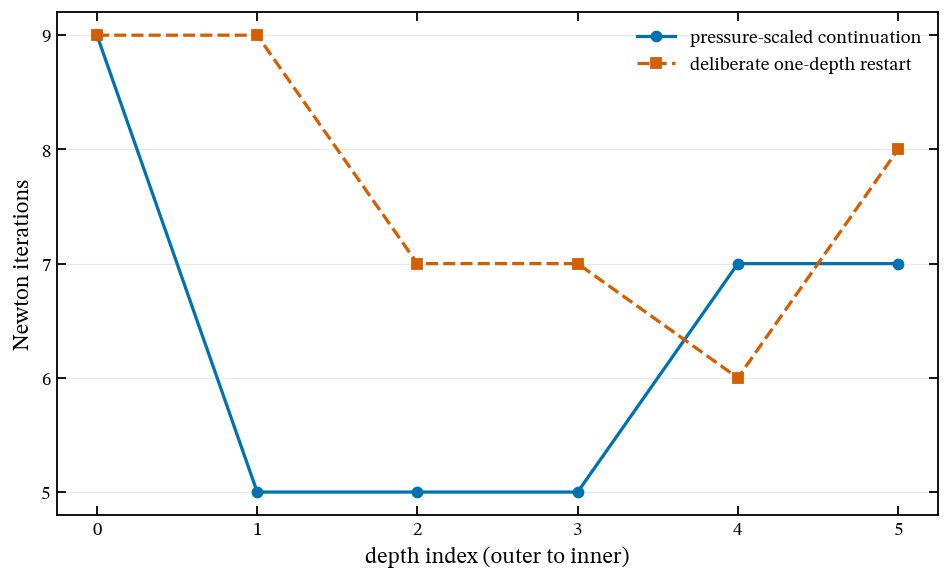

pressure-scaled seeds exact: True
all depths converged: True
published CPU-float64 iteration parity: True


In [12]:
continuation = atmosphere_continuation_checkpoint(molecular_inputs)
figure, axes = single_panel()
axes.plot(
    continuation.depth_index, continuation.continuation_iteration_count,
    marker="o", color=PAPER_COLORS["blue"],
    label="pressure-scaled continuation",
)
axes.plot(
    continuation.depth_index,
    continuation.restart_iteration_count,
    marker="s", ls="--", color=PAPER_COLORS["orange"],
    label="deliberate one-depth restart",
)
axes.set(
    xlabel="depth index (outer to inner)",
    ylabel="Newton iterations",
    xticks=continuation.depth_index,
    yticks=np.arange(5, 10),
)
add_quiet_grid(axes, axis="y")
axes.legend()
plt.show()
plt.close(figure)
with np.load(
    golden_directory
    / "chapter04_atmosphere_molecular_state_cpu_float64.npz",
    allow_pickle=False,
) as reference:
    exact_iterations = np.array_equal(
        continuation.continuation_iteration_count,
        reference["full_newton_iteration_count"],
    )
print("pressure-scaled seeds exact:", continuation.continuation_seed_equal.all())
print("all depths converged:", continuation.continuation_converged.all())
print("published CPU-float64 iteration parity:", exact_iterations)


Compilation removes Python overhead from repeated local arithmetic; it does not
erase the causal arrow from depth \(d-1\) to depth \(d\). The decorator options
have separate meanings:

- `@njit` compiles a restricted numerical Python function for concrete array
  dtypes and shapes;
- `cache=True` permits compiled machine code to be reused by a later process, so a
  cold compilation and a warm call are different measurements;
- `nogil=True` releases Python's global interpreter lock while compiled code runs;
  it does not create threads;
- `parallel=True` and `prange` are for loop iterations that are genuinely
  independent.

The local formation-constant, residual/Jacobian, update, and energy kernels are
compiled. The LAPACK linear solve remains outside them. Since depth \(d\) consumes
the returned root from \(d-1\), this molecular solve has no scientifically valid
all-depth `prange` replacement and no atmosphere molecular GPU route.

## 4.11 Preserve the physical seed and earn molecular internal energy

After a normal solve, the live equation array is transformed for population
normalization. A separate saved `(depth, 23)` array therefore owns the physical
warm start. In molecular specific-energy mode, a nonzero saved row overrides the
usual pressure-scaled seed, remains preserved, and the solver returns after
evaluating the full molecular energy.

Beyond the translation term \(1.5P_{\rm gas}/\rho\), a molecule contributes its
binding and partition response. If \(D_m>0\) denotes a dissociation energy, its
signed contribution is
\(n_m[-D_m+kT\,\partial\ln Q_m/\partial\ln T]/\rho\): binding lowers the stored
energy relative to separated particles. The finite response used by the
implementation is

\[
\frac{Q(1.001T)-Q(0.999T)}
     {\max[Q(1.001T)+Q(0.999T),10^{-30}]}\,1000 .
\]


In [13]:
atmosphere_state = compute_atmosphere_molecular_state(molecular_inputs)
molecular_state = atmosphere_state.molecular_state
runtime_state = atmosphere_state.runtime_state
from payne_zero_atmosphere import molecular_equilibrium as atmosphere_molecules
saved_physical = (
    molecular_state.previous_molecular_equation_densities.copy()
)
normalized_seed = (
    molecular_state.partition_normalized_molecular_populations.copy()
)
translation_energy = runtime_state.specific_internal_energy.copy()
atmosphere_molecules.restore_molecular_equation_density(
    molecular_state, saved_physical.copy()
)
molecular_state.partition_normalized_molecular_populations[:] = (
    normalized_seed
)
atmosphere_molecules.set_molecular_specific_internal_energy_mode(
    molecular_state, True
)
atmosphere_molecules.solve_molecular_equilibrium(
    molecular_state,
    population_mode=1,
)
full_energy = runtime_state.specific_internal_energy.copy()
print(
    "saved physical rows preserved:",
    np.array_equal(
        saved_physical,
        molecular_state.previous_molecular_equation_densities,
    ),
)
print("translation-only u at depth 0:", f"{translation_energy[0]:.6e}")
print("molecule-aware u at depth 0:", f"{full_energy[0]:.6e}")
print("energy changed somewhere:", np.any(full_energy != translation_energy))


saved physical rows preserved: True
translation-only u at depth 0: 3.268175e+11
molecule-aware u at depth 0: 3.229021e+11
energy changed somewhere: True


The saved physical array survives while the energy changes. Modes 2 and 12 and the
energy path have deliberately different early-return lifecycles; they are not
interchangeable population calls.

There is one orchestration boundary we must name without jumping ahead to
opacity and transfer. `AtmosphereConfig` defaults
`molecular_convection_thermal_tracks_perturbation=True`, and the product runner
explicitly forwards that value. The lower-level convection sampler and transfer
finalizer both default the corresponding argument to `False`. The cell above calls
the chemistry-side energy mode directly, so it neither claims nor inherits either
convection default. When atmosphere iteration later executes the product runner, it
will make four temperature/pressure perturbations after opacity and transfer exist.
Here we pin only the saved-state and energy side effect that orchestration consumes.

The three chemistry routes have different lifecycle contracts:

| route | saved physical rows | transform live columns | normalized fill | energy |
|---|---|---|---|---|
| normal mode 1 | replace with solved rows | yes | yes | translation only |
| mode 2 or 12 | replace with solved rows | no | no | unchanged |
| energy mode | preserve restored rows | no | no | full molecular value |

The full runner restores saved runtime and molecular arrays after a
perturbed-temperature energy evaluation, so this diagnostic route does not silently
become the next ordinary population state.

> **Movement II close.** The atmosphere molecular solver is CPU NumPy `float64`.
> Numba compiles its local chemistry kernels, LAPACK supplies the linear step, and
> an order-sensitive density update keeps the iterate positive. Pressure-scaled
> continuation prevents molecular depth parallelism.

> **Movement III — Cross the atmosphere/synthesis boundary honestly.** The
> synthesis implementation preserves the coupled root but changes the derivative,
> scaling, positivity, precision, and public electron-density contracts.

## 4.12 Execute one exact synthesis Newton step

Synthesis still solves for ordinary number densities in cm\(^{-3}\). It does not
optimize their logarithms; neither backend uses logarithmic Newton unknowns.
Logarithms appear only while evaluating a molecular
product, where direct multiplication of many very large or small factors would be
fragile:

\[
\ln n_m=\ln K_m+\sum_a\nu_{ma}\ln x_a+(\eta_m-p_m)\ln x_e .
\]

Here \(\eta_m\) and \(p_m\) have distinct encodings. Equation code `100` is the
ordinary electron equation and increments \(\eta_m\); component sentinel `101`
increments \(p_m\); molecule code `101.0` is H\(_2\). Similar-looking numbers
therefore have different owners. All 14 shared negative-ion records place one
ordinary code-100 electron component last, so \(\eta_m=1\), \(p_m=0\), and
\(q_m=-1\). Their product contains \(x_e\), while their charge contribution is
negative. Positive ions use one or more inverse-electron sentinels, so \(p_m>0\)
and \(q_m>0\).

`jacrev` asks PyTorch to differentiate the exact residual with respect to its
23-density vector. The resulting columns span very different CGS scales, so with

\[
s_j=\max(|x_j|,\epsilon_{\rm tiny}),
\]

the solver obtains a fractional correction from

\[
[J\,{\rm diag}(\mathbf{s})]\boldsymbol{\delta}_{\rm frac}
=\mathbf{R},\qquad
\boldsymbol{\delta}=\mathbf{s}\odot\boldsymbol{\delta}_{\rm frac}.
\]

It measures the undamped fractional update first, applies the 0.69 sign-reversal
damping second, and finally replaces any too-small candidate with
`current_density / 100`. Column scaling changes the linear algebra, not the
physical unknowns.


In [14]:
synthesis_step = synthesis_newton_checkpoint(depth_index=0)
density = torch.tensor(synthesis_step.density_before_cm3, dtype=torch.float64)
residual = torch.tensor(synthesis_step.residual_cm3, dtype=torch.float64)
jacobian = torch.tensor(synthesis_step.jacrev_jacobian, dtype=torch.float64)
tiny = torch.tensor(torch.finfo(torch.float64).tiny)
column_scale = torch.maximum(torch.abs(density), tiny)
fractional_step = torch.linalg.solve(
    jacobian * column_scale[None, :], residual
)
physical_step = column_scale * fractional_step
overflow = synthesis_step.nonfinite_product
print("device / dtype:", synthesis_step.device_type, synthesis_step.torch_dtype)
print("equation width:", synthesis_step.density_before_cm3.size)
print("visible scaled solve exact:", torch.equal(
    physical_step, torch.tensor(synthesis_step.physical_step_cm3)))
print("maximum finite-difference scale-relative error:",
      f"{synthesis_step.max_finite_difference_scale_relative_error:.3e}")
print("scaled linear residual / residual norm:",
      f"{synthesis_step.scaled_linear_residual_relative_norm:.3e}")
print("maximum undamped fractional update:",
      f"{synthesis_step.maximum_fractional_update:.3e}")
print("positivity-floor entries:",
      np.count_nonzero(synthesis_step.positivity_floor_mask))
print("controlled 0.69 sign damping:", synthesis_step.sign_damping.sign_change)
print("controlled overflow becomes zero:", overflow.replacement_applied,
      overflow.post_replacement_product)
print("physical nonfinite replacements:",
      synthesis_step.physical_nonfinite_replacement_count)
print("direct tolerance:", synthesis_step.convergence_tolerance)
print("observed order:",
      " -> ".join(synthesis_step.call_order.operation_order))


device / dtype: cpu torch.float64
equation width: 23
visible scaled solve exact: True
maximum finite-difference scale-relative error: 1.000e-08
scaled linear residual / residual norm: 1.538e-17
maximum undamped fractional update: 9.005e+00
positivity-floor entries: 2
controlled 0.69 sign damping: True
controlled overflow becomes zero: True 0.0
physical nonfinite replacements: 0
direct tolerance: 0.001
observed order: production residual -> torch.func.jacrev Jacobian -> density-column-scaled solve -> undamped relative-update convergence test -> 0.69 sign damping -> candidate density -> current_density/100 positivity floor


`jacrev` and the independent finite difference agree at one physical depth. Column
scaling makes the linear solve accurate, but the maximum fractional correction is
about nine: this early iterate is not yet chemically closed, and two components
need the positivity floor.

<figure>
  <img src="assets/schematics/textbook/ch04-newton-positivity-v1.png"
       alt="A conceptual residual forks into atmosphere and synthesis density-space lanes; both damp the correction before forming a candidate, then apply distinct positivity rules.">
  <figcaption><strong>Conceptual map: one root, two numerical
  policies.</strong> Both backends solve for ordinary densities and apply their
  0.69 sign-history damping before forming \(x-\delta\). The atmosphere uses an
  analytic Jacobian, an unscaled solve, absolute reflection, and a shared scale;
  synthesis uses `jacrev`, density-column scaling, and a current-density/100
  floor.</figcaption>
</figure>

The observed operation order also matters. `vmap` means “apply one array function
across a batch dimension”; it evaluates final molecular populations only after
every ordered depth has completed its Newton loop. It is not an all-depth Newton
solver.

Four exact safeguards and limitations belong to this implementation contract:

- synthesis stores \(\ln K=-700\) when a formation constant is nonpositive, so
  that residual contribution is tiny rather than algebraically absent;
- a nonfinite product inside the synthesis residual is replaced by zero, as the
  controlled output above shows, but the final post-loop population evaluation
  has no matching guard;
- the low-level direct synthesis solve uses a \(10^{-3}\) update tolerance, while
  the production population wrappers used here request \(10^{-4}\);
- at 200 iterations, both molecular backends return their last iterate rather than
  raise. A returned vector is therefore not automatically a converged vector; the
  textbook's accepted routes separately reject exhausted depths.

The device and dtype boundaries are route-specific:

| boundary | exact policy |
|---|---|
| atmosphere molecular solve | CPU NumPy/Numba `float64`; no GPU route |
| direct synthesis molecular call, dtype omitted | `torch.float32` |
| public synthesis runtime, dtype omitted | `float64` on CPU/CUDA; `float32` on MPS |
| explicit public MPS `float64` | rejected |
| explicit direct-solver MPS `float64` | silently substituted by `float32` |
| full route with off-MPS float32 tables | call 0 may use reference `float64`; call 1 uses table `float32` |

Whole-spectrum accelerator parity belongs only after opacity and transfer have been
assembled. Here the point is narrower: dtype ownership is part of the
molecular-route interface and must be recorded for both full-route calls.

<figure>
  <img src="assets/schematics/textbook/ch04-ordered-backends-v1.png"
       alt="A conceptual pair of outer-to-inner depth chains compares atmosphere Numba kernels and CPU LAPACK with synthesis jacrev inside each depth and vmap only after the final depth.">
  <figcaption><strong>Conceptual map: ordered in both
  backends.</strong> Synthesis can run on an accelerator, but its Newton loop
  still walks depths in order. `jacrev` belongs inside one depth and iteration;
  `vmap` evaluates final molecular populations only after all Newton loops
  finish.</figcaption>
</figure>

## 4.13 Run the full synthesis route and retain both molecular solves

The full synthesis EOS first closes electron density, then performs a second
molecular solve at the published electron column. These calls answer different
questions, so their internal electron arrays need not be identical. The public
`PopulationState.electron_density` belongs to the first call; the final molecular
populations belong to the second.

Before either molecular call, the full EOS route constructs the electron seed used
for its atomic-ion formation constants. At the outer depth,
\(n_{e,\rm seed}=P_{\rm gas}/(20k_{\rm B,ref}T)\); later depths use the upstream
electron density times \(P_d/P_{d-1}\), with a \(10^{-300}\) floor. This seed is
distinct from the internal cold-chain density in Section 4.10 and does not replace
the molecular charge equation.


In [15]:
full_synthesis = compute_synthesis_molecular_state(
    molecular_inputs,
    fixed_electron_density=False,
)
with np.load(
    golden_directory
    / "chapter04_synthesis_molecular_full_cpu_float64.npz",
    allow_pickle=False,
) as reference:
    electron_exact = np.array_equal(
        full_synthesis.electron_density,
        reference["call_0__output__electron_density"],
    )
    molecules_exact = np.array_equal(
        full_synthesis.molecular_populations,
        reference["call_1__output__molecular_populations"],
    )
    call_count = int(reference["trace__molecular_call_count"])
print("public electron source: molecular call 0")
print("public molecule source: molecular call 1")
print("owned molecular calls:", call_count)
print("electron column exact CPU-float64 parity:", electron_exact)
print("molecular array exact CPU-float64 parity:", molecules_exact)
print("call-1 internal electron differs at depths:",
      np.count_nonzero(
          full_synthesis.molecular_equation_densities[:, 22]
          != full_synthesis.electron_density))
print("active/padded molecular shape:",
      full_synthesis.molecular_populations.shape)


public electron source: molecular call 0
public molecule source: molecular call 1
owned molecular calls: 2
electron column exact CPU-float64 parity: True
molecular array exact CPU-float64 parity: True
call-1 internal electron differs at depths: 5
active/padded molecular shape: (6, 200)


The padded synthesis molecular array has shape `(depth, 200)`, while only 190
columns are active. The final ten remain exactly zero. A direct call must declare
device and dtype when parity matters; CPU `float64`, CUDA, and MPS do not inherit
one universal precision claim.

## 4.14 Hold the public electron density fixed

A structured atmosphere already supplies an electron density. The fixed route
therefore promises to *publish that input column unchanged*. Its internal
molecular root still contains an electron equation and can return a different
diagnostic electron density. That internal value is evidence, not the public
state. Mass density may either be derived or supplied explicitly.


In [16]:
fixed_derived = compute_synthesis_molecular_state(
    molecular_inputs,
    fixed_electron_density=True,
)
atomic_masses = load_npz_arrays(SYNTHESIS_ATOMIC_MASSES)["atomic_mass_amu"][:99]
abundance = molecular_inputs["elemental_abundances"]
mean_mass = np.sum(abundance * atomic_masses) / np.sum(abundance)
ideal_gas_density_scale = (
    molecular_inputs["gas_pressure"]
    / molecular_inputs["temperature"]
    / REFERENCE_BOLTZMANN_ERG_PER_K
)
supplied_mass = (
    ideal_gas_density_scale * mean_mass * REFERENCE_ATOMIC_MASS_GRAM
)
fixed_supplied = compute_synthesis_molecular_state(
    molecular_inputs,
    fixed_electron_density=True,
    mass_density=supplied_mass,
)
public_e_preserved = np.array_equal(
    fixed_derived.electron_density,
    molecular_inputs["electron_density_seed"],
)
print("derived route preserves public input electron:", public_e_preserved)
print("internal molecular electron differs:",
      np.any(fixed_derived.molecular_equation_densities[:, 22]
             != fixed_derived.electron_density))
print("supplied route preserves mass density:",
      np.array_equal(fixed_supplied.mass_density, supplied_mass))
print("derived and supplied masses differ:",
      np.any(fixed_derived.mass_density != fixed_supplied.mass_density))


derived route preserves public input electron: True
internal molecular electron differs: True
supplied route preserves mass density: True
derived and supplied masses differ: True


“Fixed” names the public electron contract; it does not claim that every internal
equation returns the same electron value. Keeping those claims separate prevents a
diagnostic array from silently replacing the atmosphere input.

## 4.15 Audit route ownership instead of blending routes

The phrase “prepare populations” now hides several distinct ownership rules:

| route | public electron owner | molecular behavior |
|---|---|---|
| atmosphere, enabled | atmosphere solve | one ordered solve |
| atmosphere, pressure iteration disabled | fresh seed | no population fill |
| atmosphere structured handoff | coupled solve may move input | solve, then packed refill |
| atmosphere live/debug bridge | atmosphere output | diagnostic only; active/padded shapes conflict |
| synthesis full | molecular call 0 | two solves; call 1 supplies molecules |
| synthesis fixed | caller input | one internal solve; its electron is diagnostic |
| public molecular-lines release | solved atmosphere input | rebuild with 190-record catalog; arrays reused |
| atom-only pipeline fallback | upstream public input | fixed solve only when molecule arrays are absent |

These are contracts, not interchangeable ways to obtain “the same state.”


In [17]:
handoff = compute_atmosphere_molecular_state(
    molecular_inputs, structured_handoff=True)
disabled = compute_atmosphere_molecular_state(
    molecular_inputs, pressure_iteration_enabled=False)
release_inputs = dict(molecular_inputs)
release_inputs["electron_density_seed"] = (
    handoff.runtime_state.electron_density.copy())
public_lane = build_public_molecular_lane_checkpoint(release_inputs)
route_edges = molecular_route_boundary_checkpoint(molecular_inputs, handoff)
checks = {
    "handoff electron changed": np.any(
        handoff.runtime_state.electron_density
        != molecular_inputs["electron_density_seed"]),
    "disabled molecular cells": np.count_nonzero(
        disabled.molecular_state.molecular_populations),
    "release electron exact": np.array_equal(
        public_lane.fixed_population_state.electron_density,
        handoff.runtime_state.electron_density),
    "release arrays reused": public_lane.reused_fixed_molecular_arrays,
    "live error / shapes": (
        route_edges.live_shape_error_type,
        route_edges.padded_molecule_code_shape,
        route_edges.active_molecular_population_shape),
    "mixed H2 is catalog": np.array_equal(
        route_edges.h2_mixed_output,
        route_edges.h2_mixed_catalog_input),
    "zero H2 is analytic": np.array_equal(
        route_edges.h2_all_zero_output,
        route_edges.h2_no_catalog_output),
    "fallback fixed / molecular calls": (
        route_edges.fallback_fixed_eos_call_count,
        route_edges.fallback_molecular_solve_call_count),
}
for label, value in checks.items():
    print(f"{label:34s}", value)


handoff electron changed           True
disabled molecular cells           0
release electron exact             True
release arrays reused              True
live error / shapes                ('ValueError', (200,), (6, 170))
mixed H2 is catalog                True
zero H2 is analytic                True
fallback fixed / molecular calls   (1, 1)


The pressure-disabled result is an empty phase, not a hidden fixed-density solve.
The structured handoff reports both sides of its boundary rather than promising
preservation. The release checkpoint above deliberately feeds that solved atmosphere
electron column into the fixed public builder; it does not publish the uncontrolled
fixture seed as a “closed” atmosphere.

Two diagnostic seams must not be mistaken for that release route:

- the pinned live/debug bridge presents 200 padded synthesis codes beside 170 active
  atmosphere populations, so its unsliced array shapes are incompatible;
- its H\(_2\) choice is global: if *any* catalog H\(_2\) value is positive, the
  complete catalog vector is selected, including zero entries. Only an all-zero
  vector uses the provisional analytic H\(_2\) estimate.

The release path avoids that mixed-catalog bridge. It rebuilds molecular support
through the 190-record synthesis catalog. If a structured input arrives without
molecule-backed arrays, the pipeline owns a separate fallback fixed solve; the
accepted release fixture already has those arrays, so its fallback count is zero
and the single solved result is reused.

In the packed atmosphere path, one zero-code priming call owns the molecular solve
for a temperature index; the 230 scheduled reads then reuse that state. Packed
Doppler slots 919 and 927 remain structural `+inf` values with zero isotope mass
and zero actual and normalized population. They are empty layout slots, not
infinite physical broadening, and must not be “sanitized” into a finite value.

<figure>
  <img src="assets/schematics/textbook/ch04-catalog-to-public-lane-v1.png"
       alt="A 170-record atmosphere catalog sits within a 190-record synthesis catalog, while 54 line-list species mappings point into selected cells of normalized stage index 5; a separate card states that the actual ion-stage cube is unchanged.">
  <figcaption><strong>Conceptual map: catalog identity is not a public array
  index.</strong> The catalogs align by chemical code and component semantics. A
  separate mapping sends 54 line-list species into selected normalized stage-5
  cells, while the actual ion-stage cube remains atomic.</figcaption>
</figure>

## 4.16 Align catalogs by code and component semantics

Row 45 in one catalog need not mean row 45 in another. We form an integerized code
key, then compare the component species and coefficients of every shared record.
For this pinned pair, all 170 atmosphere records are shared and the synthesis
catalog adds 20.


In [18]:
summary = molecular_catalog_summary()
synthesis_only_codes = (
    summary["synthesis_only_code_keys"].astype(np.float64) / 100.0
)
atmosphere_count = int(summary["atmosphere_counts"][0])
synthesis_count = int(summary["synthesis_counts"][0])
print("atmosphere active records:", atmosphere_count)
print("synthesis active records:", synthesis_count)
print("shared records:", atmosphere_count)
print("atmosphere-only records:", 0)
print("synthesis-only records:", synthesis_only_codes.size)
print("shared semantic mismatches:",
      np.count_nonzero(summary["shared_semantic_mismatch"]))
print("shared records at different rows:",
      np.count_nonzero(summary["shared_row_reordered"]))
print("exact synthesis-only codes:")
print(synthesis_only_codes)


atmosphere active records: 170
synthesis active records: 190
shared records: 170
atmosphere-only records: 0
synthesis-only records: 20
shared semantic mismatches: 0
shared records at different rows: 64
exact synthesis-only codes:
[1.11000000e+02 1.08110000e+04 1.08120000e+04 1.08200000e+04
 6.06060000e+04 6.06080000e+04 6.06140000e+04 6.08160000e+04
 6.14140000e+04 6.16160000e+04 7.07080000e+04 7.08080000e+04
 8.08140000e+04 8.08160000e+04 1.01010600e+06 1.01010700e+06
 1.01060600e+06 6.06070700e+06 1.01010106e+08 1.01010114e+08]


This is a strict code-semantic extension for the pinned catalogs, not a promise that
future files will append rows in the same order. Indeed, 64 shared records already
occupy different rows. Identity comes from the integerized code, ordered component
semantics, and coefficients. Padding, electron sentinels, and inverse-electron
sentinels remain storage and equation conventions—not extra molecules.

## 4.17 Map normalized molecules into the public synthesis lane

Line opacity needs \(N_m/U_m\), not raw \(N_m\). The fixed public builder
therefore repurposes selected cells in stage index 5 of
`partition_normalized_populations`. It does **not** overwrite the corresponding
cells of `ion_stage_populations`. At an owned coordinate those two cubes no longer
mean “\(n\) and \(n/U\) for one atomic ion”: the actual cube remains atomic, while
the normalized cube carries molecular line support.

Four identifiers must stay distinct: molecular catalog code, line-list species
code, public species column, and synthetic stage index.

The line basis begins by transforming each neutral elemental equation density:

\[
\widetilde n_Z=
\frac{n_Z}
{U_{Z,0}(1.8786\times10^{20})(m_ZT)^{3/2}},
\]

where \(m_Z\) is the atomic mass in amu—not the elemental abundance \(A_Z\)
used in the conservation ledger. For an ordinary polynomial molecule,

\[
\frac{N_m}{U_m}
=
\exp\!\left[\frac{a_0}{T/11604.5}\right]
\left(\prod_i\widetilde n_i\right)
(1.8786\times10^{20})(m_mT)^{3/2}.
\]

An inverse-electron sentinel divides this product by the transformed electron
basis. Here \(m_m\) is the molecular mass in amu. For CO, the components are C and
O, \(a_0=11.091\ {\rm eV}\), and
\(m_{\rm CO}=12.01+16.0=28.01\ {\rm amu}\). The public address then follows

\[
276\ {\rm(line\ species)}
\longrightarrow 608\ {\rm(equilibrium\ code)}
\longrightarrow [d,5,45].
\]


In [19]:
mapped = public_lane.partition_cube_after[:, 5, public_lane.public_columns]
actual_unchanged = np.array_equal(
    public_lane.ion_cube_before, public_lane.ion_cube_after)
normalized_exact = np.array_equal(
    mapped, public_lane.no_ground_line_populations)
print(
    "CO address: line species -> equilibrium code -> public cell:",
    f"{public_lane.co_line_species_code} -> "
    f"{public_lane.co_equilibrium_code:.0f} -> "
    f"[depth, 5, {public_lane.co_public_column}]",
)
print("actual ion cube unchanged everywhere:", actual_unchanged)
print("all owned normalized cells equal N_m/U_m:", normalized_exact)
print("independent CO reconstruction exact:",
      np.array_equal(public_lane.co_independent_population,
                     public_lane.co_normalized_population))
print("raw CO differs at every depth:",
      np.all(public_lane.co_raw_population
             != public_lane.co_normalized_population))
print("no-ground/ground values differ:",
      np.count_nonzero(public_lane.ground_discrimination_mask))
print("schema / H II shape:",
      public_lane.structured_atmosphere["atmosphere_schema_version"],
      public_lane.structured_atmosphere["hydrogen_ionized_population"].shape)
from payne_zero_atmosphere.continuum_opacity import build_continuum_atmosphere_state
atmosphere_continuum_state = build_continuum_atmosphere_state(
    handoff.setup.atmosphere, handoff.runtime_state)
packed_normalized = (
    handoff.runtime_state.partition_normalized_populations_by_packed_slot)
print("atmosphere fields / exact CH-OH normalized slots:",
      len(atmosphere_continuum_state.__dataclass_fields__),
      np.array_equal(atmosphere_continuum_state.ch_population,
                     packed_normalized[:, 845]),
      np.array_equal(atmosphere_continuum_state.oh_population,
                     packed_normalized[:, 847]))


CO address: line species -> equilibrium code -> public cell: 276 -> 608 -> [depth, 5, 45]
actual ion cube unchanged everywhere: True
all owned normalized cells equal N_m/U_m: True
independent CO reconstruction exact: True
raw CO differs at every depth: True
no-ground/ground values differ: 11
schema / H II shape: [4] (6,)
atmosphere fields / exact CH-OH normalized slots: 18 True True


CO follows `276 → 608 → [depth, 5, 45]`. All 54 mappings are unique: 51
destination columns lie inside 0–98 and only 129–131 lie in the unused tail of the
atom-only state. The actual ion cube is unchanged everywhere; every owned
normalized cell equals the exact no-ground-partition line mapper, while CO also
matches the separate algebraic reconstruction derived above. The grounded
counterfactual differs, proving that this lane cannot reuse the ordinary grounded
atomic partitions. Molecular normalization also uses its own hard-coded mass
authority, whose identity is checked separately from `atomic_masses.npz`.

The atmosphere schedule contains 230 jobs: 198 inherited atomic jobs plus two
normalized reads for each of 16 selected molecular codes.

There are now **two** closed consumer views, not one universal atmosphere
dictionary.

The CPU atmosphere continuum receives an 18-field
`ContinuumAtmosphereState` built from the solved `ModelAtmosphere` and
`AtmosphereRuntimeState`. Its two broad packed arrays retain the atmosphere's
1006-slot layout:

| exact field or fields | shape and axes | physical role or unit |
|---|---|---|
| `temperature`, `gas_pressure` | each `(D,)` depth | K; dyn cm\(^{-2}\) |
| `mass_density`, `electron_density` | each `(D,)` depth | g cm\(^{-3}\); cm\(^{-3}\) |
| `hydrogen_partition_normalized_ion_stage_populations` | `(D,2)` depth, first two stages | cm\(^{-3}\) per partition function |
| `hydrogen_neutral_population`, `hydrogen_ionized_population` | each `(D,)` depth | cm\(^{-3}\) |
| `helium_neutral_population`, `helium_singly_ionized_population` | each `(D,)` depth | cm\(^{-3}\) |
| `helium_neutral_partition_normalized_population`, `helium_singly_ionized_partition_normalized_population` | each `(D,)` depth | cm\(^{-3}\) per partition function |
| `elemental_abundances_by_layer` | `(D,99)` depth, atomic number 1–99 | nuclei fraction |
| `hydrogen_departure_coefficients` | `(D,6)` depth, explicit H I level | dimensionless |
| `microturbulence` | `(D,)` depth | cm s\(^{-1}\) |
| `ion_stage_populations_by_packed_slot`, `partition_normalized_populations_by_packed_slot` | each `(D,1006)` depth, packed slot | cm\(^{-3}\) |
| `ch_population`, `oh_population` | each `(D,)` depth | exact aliases of partition-normalized packed slots 845 and 847, in cm\(^{-3}\) |

The last two names are easy to misread. They are not generic actual-molecule
fields: the adapter copies \(N_{\rm CH}/U_{\rm CH}\) and
\(N_{\rm OH}/U_{\rm OH}\). Chapter 5's corresponding cross-section helpers carry
the partition factor, so their product recovers the required absorber density.

The device synthesis continuum instead receives the separate 27-field schema-v4
handoff. Let \(D\) be the outer-to-inner depth axis, \(J=0,\ldots,5\) the
neutral-through-five-times-ionized stage axis, \(S=0,\ldots,138\) the public
species-slot axis, and \(E=341\) the continuum-edge node axis. Every floating
array below is host NumPy `float64`:

| exact field or fields | shape and axes | physical unit |
|---|---|---|
| `temperature` | `(D,)` depth | K |
| `column_mass` | `(D,)` depth | g cm\(^{-2}\) |
| `gas_pressure` | `(D,)` depth | dyn cm\(^{-2}\) |
| `electron_density` | `(D,)` depth | cm\(^{-3}\) |
| `mass_density` | `(D,)` depth | g cm\(^{-3}\) |
| `microturbulence` | `(D,)` depth | cm s\(^{-1}\) |
| `hc_over_kt` | `(D,)` depth | cm |
| `hydrogen_neutral_population`, `hydrogen_ionized_population` | each `(D,)` depth | cm\(^{-3}\) |
| `helium_neutral_population`, `helium_singly_ionized_population` | each `(D,)` depth | cm\(^{-3}\) |
| `molecular_hydrogen_population` | `(D,)` depth | cm\(^{-3}\) |
| `hydrogen_partition_normalized_ion_stage_populations`, `carbon_partition_normalized_ion_stage_populations` | each `(D, 2)` depth, first two stages | cm\(^{-3}\) |
| `magnesium_neutral_partition_normalized_population`, `aluminum_neutral_partition_normalized_population`, `silicon_neutral_partition_normalized_population`, `iron_neutral_partition_normalized_population` | each `(D,)` depth | cm\(^{-3}\) |
| `partition_normalized_populations` | `(D, 6, 139)` depth, \(J\), \(S\) | cm\(^{-3}\) |
| `ion_stage_populations` | `(D, 6, 139)` depth, \(J\), \(S\) | cm\(^{-3}\) |
| `fractional_doppler_widths` | `(D, 6, 139)` depth, \(J\), \(S\) | dimensionless \(v_D/c\) |
| `elemental_abundances` | `(99,)` atomic number 1–99 | nuclei fraction |
| `signed_continuum_edge_frequency_hz` | `(E,)` edge node | Hz |
| `continuum_edge_wavelength_nm` | `(E,)` edge node | nm |
| `continuum_edge_midpoint_wavelength_nm` | `(E-1,)` interval | nm |
| `continuum_edge_interval_width_squared_over_two_nm2` | `(E-1,)` interval | nm\(^2\) |
| `atmosphere_schema_version` | `(1,)`, NumPy `int32`, value `[4]` | dimensionless |

A partition function is dimensionless, so a population divided by \(U\) still has
units cm\(^{-3}\). Chapter 5 consumes these two closed views without reopening
chemical equilibrium: the 18-field packed adapter for atmosphere opacity and the
27-field schema-v4 mapping for synthesis opacity.

## 4.18 Chapter summary

We began with one CO molecule spending one carbon and one oxygen budget. That
simple fact forced the rest of the chapter:

- mass action supplies molecular populations for trial free densities;
- simultaneous particle, element, and charge conservation choose one coupled
  density-space root;
- both exact backends follow pressure-scaled depth continuation in order;
- molecular products may use logarithms, but neither backend uses logarithmic Newton
  unknowns;
- atmosphere and synthesis deliberately use different Jacobian, scaling, and
  positivity policies;
- atmosphere, full synthesis, fixed-public-electron, diagnostic, and release routes
  own different electron and population claims;
- the 170- and 190-record catalogs and the three H2 policies are distinct,
  checksum-bound inputs;
- raw molecular populations, saved physical equation densities, transformed
  equation columns, and partition-normalized line populations are not
  interchangeable;
- atmosphere-continuum packed state and synthesis schema-v4 state are separate
  consumer views, even when they describe the same depth column;
- the public synthetic lane now contains verified \(N_m/U_m\) values while the
  actual ion-stage cube remains atomic.

### Next: let the particles interact with light

[Chapter 5: Continuous Opacity and Scattering](/reader.html?ch=5) starts from
the two closed consumer views built here and asks which continuum processes
remove or redirect photons. It will not reopen the molecular equilibrium solve
or pretend that the packed CPU state and schema-v4 device state are one mapping.
